# The Hubbard and t-J models: exact diagonalisation (ED) on chain, square and checkerboard lattices

Here, we define two canonical models of strongly correlated electrons: the Hubbard model and its descendant the t-J model, and diagonalise them exactly in a fixed $(N_\uparrow, N_\downarrow)$ sector, with the lattice type, total number of sites $N=L$ in 1D or $N=L^2$ in 2D, and the solver (full ED or Lanczos) as user parameters.

**The Hubbard model** with hopping amplitude $t_{ij}$ between nearest neighbour sites $\langle ij \rangle$ and on-site Coulomb repulsion $U$:

$$H_{\mathrm{Hubbard}} \;=\; -\sum_{\langle ij \rangle\,\sigma} t_{ij}\,
\big(c^\dagger_{i\sigma} c_{j\sigma} + \mathrm{h.c.}\big)
\;+\; U \sum_i n_{i\uparrow} n_{i\downarrow}.$$

**The t-J model** — the strong-coupling ($U \gg t$) limit of the Hubbard model, with $J_{ij} = 4t_{ij}^2/U$ and the Gutzwiller projector $P_G$ removing all doubly occupied sites:

$$H_{tJ} \;=\; P_G\Big[-\sum_{\langle ij \rangle\,\sigma} t_{ij}\,
\big(c^\dagger_{i\sigma} c_{j\sigma} + \mathrm{h.c.}\big)\Big] P_G
\;+\; \sum_{\langle ij \rangle} J_{ij}\, \left[\mathbf{S}_i\cdot\mathbf{S}_j -\tfrac14\,P_Gn_i n_j P_G\right].$$

(The t-J model is often defined without the density–density term $-\tfrac14\sum_{\langle ij \rangle} J_{ij}\,P_Gn_i n_j P_G$, and we have left out by default here; set `TJ_DENSITY_TERM = True` in Section 1 to include it. It does indeed appear when doing the expansion of the Hubbard model for $t \ll U$.)

Both Hamiltonians conserve total $S^z$ (equivalently $N_\uparrow$ and $N_\downarrow$), so we constrain ED to distinct $(N_\uparrow$, $N_\downarrow)$-sectors. The Hubbard model then has dimension $\binom{N}{N_\uparrow}\binom{N}{N_\downarrow}$ and factorises as up $\otimes$ down (Section 4); the t-J model is the no-double-occupancy subspace of dimension $\binom{N}{N_h}\binom{N-N_h}{N_\uparrow}$ with $N_h$ holes, encoded with a uint64 two-mask scheme and combinadic $O(1)$ indexing (Section 3).

Lattice conventions: site $i = x\,L + y$, crossed plaquettes at $(x+y)$ even, diagonal coupling ratio $\alpha$ (Section 2). Section 6 gives some benchmarks, while Section 8 runs the parameters set below.

## 1  Parameters

Here, we specify the parameters to be run in Section 8. `LATTICE` is `'chain'` ($L$ sites), `'square'` ($L\times L$ torus) or `'checkerboard'` ($L\times L$, even $L$ if periodic). `N_UP = N_DN = None` means half filling. `METHOD = 'auto'` uses dense `eigh` up to `DENSE_CUTOFF` states and ARPACK Lanczos (`eigsh`) beyond; you can force either with `'full'` / `'lanczos'`. (For sectors $\gtrsim 10^7$, prefer `'lanczos'` together with the matrix-free operators of Section 9.)

Note that at half filling the t-J hopping is completely frozen (no empty site to hop into), so the t-J model reduces to the Heisenberg antiferromagnet — dope with `N_UP`/`N_DN` to activate the kinetic term.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import comb
from itertools import combinations
from scipy.sparse import csr_matrix, coo_matrix, identity, kron, diags
from scipy.sparse.linalg import eigsh, LinearOperator

# ---------------- user parameters ----------------
LATTICE = 'checkerboard'        # 'chain' | 'square' | 'checkerboard'
L       = 4              # chain: L sites; square/checkerboard: L x L sites
PBC     = True           # periodic boundaries (checkerboard + PBC needs even L)

MODEL   = 'tJ'           # 'hubbard' or 'tJ'

T_HOP   = 1.0            # nearest-neighbour hopping t = energy unit
U_INT   = 8.0            # Hubbard on-site repulsion U/t
J_EX    = 0.0            # t-J exchange J/t (strong-coupling map: J = 4 t^2/U = 0.5 at U = 8)
ALPHA   = 1.0            # checkerboard crossed-bond ratio alpha = t'/t = J'/J (ignored otherwise)

TJ_DENSITY_TERM = False  # t-J exchange form:
                         #   True  -> J (S_i.S_j - n_i n_j/4)
                         #   False -> J  S_i.S_j             

N_UP    = 8           # sector occupations; None -> half filling
N_DN    = 7

METHOD  = 'auto'         # 'full' | 'lanczos' | 'auto'
K_EIGS  = 4              # number of lowest eigenvalues to compute
DENSE_CUTOFF = 2000      # 'auto': dense eigh up to this dimension, eigsh beyond

## 2  Lattices

A lattice is a site count `N`, a bond list `[(i, j, t_b, J_b, kind)]` and coordinates `xy` for drawing. The chain and the
square torus have only `'nn'` bonds; the checkerboard adds both diagonals on the plaquettes whose lower-left corner has $(x+y)$ even, with couplings $\alpha t$, $\alpha J$ (`'cross'` bonds).

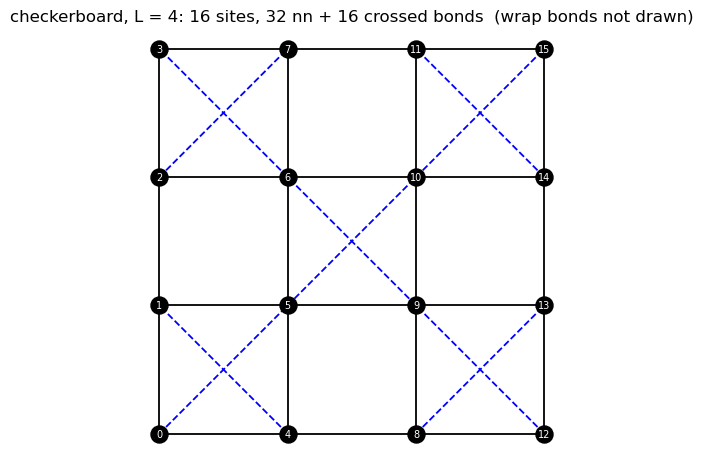

In [2]:
def _bond_collector():
    pos = {}; bonds = []                          # pos: (min,max,kind) -> index in bonds
    def add(i, j, tb, Jb, kind):
        if i == j: return
        key = (min(i, j), max(i, j), kind)
        if key in pos:                            # coincident bond -- e.g. a PBC wrap on an
            k = pos[key]                          # L=2 direction lands on the direct bond:
            oi, oj, otb, oJb, ok = bonds[k]       # sum the amplitudes (faithful torus), not drop
            bonds[k] = (oi, oj, otb + tb, oJb + Jb, ok)
        else:
            pos[key] = len(bonds); bonds.append((i, j, tb, Jb, kind))
    return bonds, add

def chain_lattice(L, J, t=1.0, pbc=True):
    bonds, add = _bond_collector()
    for i in range(L - 1): add(i, i+1, t, J, 'nn')
    if pbc and L > 1: add(L-1, 0, t, J, 'nn')   # L=2 wrap coincides with the direct bond -> summed to 2t
    xy = {i: (i, 0) for i in range(L)}
    return L, bonds, xy

def square_lattice(Lx, Ly, J, t=1.0, pbc_x=True, pbc_y=True):
    site = lambda x, y: (x % Lx)*Ly + (y % Ly)
    bonds, add = _bond_collector()
    for x in range(Lx):
        for y in range(Ly):
            if x+1 < Lx or pbc_x: add(site(x, y), site(x+1, y), t, J, 'nn')
            if y+1 < Ly or pbc_y: add(site(x, y), site(x, y+1), t, J, 'nn')
    xy = {site(x, y): (x, y) for x in range(Lx) for y in range(Ly)}
    return Lx*Ly, bonds, xy

def checkerboard_lattice(Lx, Ly, J, t=1.0, alpha=1.0, pbc_x=True, pbc_y=True):
    '''Sites i = x*Ly + y; crossed plaquettes (both diagonals, alpha*t / alpha*J) at lower-left corners with (x+y) even.'''
    site = lambda x, y: (x % Lx)*Ly + (y % Ly)
    bonds, add = _bond_collector()
    for x in range(Lx):
        for y in range(Ly):
            if x+1 < Lx or pbc_x: add(site(x, y), site(x+1, y), t, J, 'nn')
            if y+1 < Ly or pbc_y: add(site(x, y), site(x, y+1), t, J, 'nn')
    for x in range(Lx):
        for y in range(Ly):
            if (x + y) % 2: continue
            if not (x+1 < Lx or pbc_x) or not (y+1 < Ly or pbc_y): continue
            add(site(x, y), site(x+1, y+1), alpha*t, alpha*J, 'cross')
            add(site(x+1, y), site(x, y+1), alpha*t, alpha*J, 'cross')
    xy = {site(x, y): (x, y) for x in range(Lx) for y in range(Ly)}
    return Lx*Ly, bonds, xy

def build_lattice(kind, L, J=0.0, t=1.0, alpha=1.0, pbc=True):
    if kind == 'chain':
        return chain_lattice(L, J, t, pbc)
    if kind == 'square':
        return square_lattice(L, L, J, t, pbc, pbc)
    if kind == 'checkerboard':
        if pbc and L % 2:
            raise ValueError("checkerboard + PBC needs even L (crossed-plaquette pattern)")
        return checkerboard_lattice(L, L, J, t, alpha, pbc, pbc)
    raise ValueError(f"unknown lattice {kind!r}")

def hopping_matrix(N, bonds):
    '''Single-particle hopping matrix (free-fermion reference for the benchmark).'''
    T1 = np.zeros((N, N))
    for (i, j, tb, _, _) in bonds:
        T1[i, j] -= tb; T1[j, i] -= tb
    return T1

N, bonds, xy = build_lattice(LATTICE, L, J=J_EX, t=T_HOP, alpha=ALPHA, pbc=PBC)
nn = sum(1 for b in bonds if b[4] == 'nn')
fig, ax = plt.subplots(figsize=(7, 2) if LATTICE == 'chain' else (5.5, 5.5))
for (i, j, tb, Jb, kind) in bonds:
    (x1, y1), (x2, y2) = xy[i], xy[j]
    if abs(x1 - x2) > 1.5 or abs(y1 - y2) > 1.5: continue   # PBC wrap bonds are not drawn
    ax.plot([x1, x2], [y1, y2], '--' if kind == 'cross' else '-',
            color='blue' if kind == 'cross' else 'k', lw=1.3, zorder=1)
ax.scatter(*zip(*[xy[i] for i in range(N)]), s=150, marker='o', c='k', zorder=2)
for i in range(N):
    ax.annotate(str(i), xy[i], color='w', ha='center', va='center', fontsize=7, zorder=3)
ax.set_aspect('equal'); ax.set_axis_off()
ax.set_title(f"{LATTICE}, L = {L}: {N} sites, {nn} nn + {len(bonds)-nn} crossed bonds"
             + ("  (wrap bonds not drawn)" if PBC else ""))
plt.show()

## 3  Basis state encoding

Spin-orbitals are JW-ordered in two blocks: up orbitals $0,\dots,N-1$, then down orbitals $N,\dots,2N-1$. With this ordering each spin species carries its own JW string.

- **Hubbard**: The sector basis is the tensor product of an up-configuration basis and a down-configuration basis (one uint64 mask each, sorted). Hopping stays within each block, and a down hop picks up the parity of *all* up electrons twice (annihilate + create), which cancels — so $H = K_\uparrow \otimes \mathbb{1} + \mathbb{1} \otimes K_\downarrow + U\,\mathrm{diag}(\text{double occupancy})$ holds exactly, where $K_\sigma$ is the one-species hopping matrix.
- **t-J**: A constrained state is a disjoint pair of masks $(U, D)$, $U \,\&\, D = 0$ (up to 64 sites). Sector indices come from a combinadic ranking (`basisstate_to_index`/`tJ_basis`, with the binomial table `CT` sized $66\times 66$ so half filling is reachable at any size): rank the hole positions among all sites, then the up positions among the electrons — $O(1)$ per state, no index dictionary.

In [3]:
_ONE = np.uint64(1)
CT = np.zeros((66, 66), dtype=np.int64)            # CT[n, k] = C(n, k)
for n in range(66):
    for k in range(n + 1):
        CT[n, k] = comb(n, k)

def spin_basis(N, n):
    '''Sorted uint64 occupation masks of one spin species: n of N bits set.'''
    S = np.fromiter((sum(1 << p for p in c) for c in combinations(range(N), n)),
                    dtype=np.uint64, count=comb(N, n))
    S.sort()
    return S

def basisstate_to_index(U, D, N, N_h, N_up):
    '''Combinadic index of each (U, D) state in the (N_h, N_up) sector,
    vectorized: rank the hole positions among all sites, then the up positions among the spins.'''
    N_e = N - N_h
    N_dn = N_e - N_up
    full = np.uint64((1 << N) - 1)
    E = U | D
    Hm = (~E) & full
    rH = np.zeros(len(U), dtype=np.int64)          #Hole configuration index
    x = Hm.copy()
    for m in range(1, N_h + 1):                    #Hole positions, ascending
        b = x & (~x + _ONE)
        p = np.bitwise_count(b - _ONE).astype(np.int64)
        rH += CT[p, m]
        x ^= b
    rU = np.zeros(len(U), dtype=np.int64)          #Spin configuration index
    x = U.copy()
    for m in range(1, N_up + 1):                   #Up positions among the spins
        b = x & (~x + _ONE)
        slot = np.bitwise_count(E & (b - _ONE)).astype(np.int64)
        rU += CT[slot, m]
        x ^= b
    return rH * comb(N_e, N_up) + rU               #Final index

def tJ_basis(N, N_h, N_up):
    '''Builds the possible basis states in a system of N sites with N_h holes and N_up up electrons, no double occupancy.'''
    '''U, D mask arrays ordered so that basisstate_to_index(U, D) == arange(dim).'''
    N_e = N - N_h
    holes_list = list(combinations(range(N), N_h))                #Possible configurations (positions) og N_h holes on N sites
    slots_list = list(combinations(range(N_e), N_up))             #Possible configurations (on occupied sites) of N_up up spins of N_e spins
    dim = len(holes_list) * len(slots_list)                       #Total number of basis states in N_h N_dn sector
    U = np.empty(dim, np.uint64); D = np.empty(dim, np.uint64)
    full = (1 << N) - 1                                           #Corresponds to all sites occupied
    i = 0
    for hc in holes_list:                                         #Looping over the possible hole configurations
        hm = 0
        for p in hc: hm |= 1 << p                                 #Makes hm 1's where there are holes
        elec = [p for p in range(N) if not (hm >> p) & 1]         #Find all electron positions, i.e. all sites that are not holes
        full_e = full ^ hm                                        #0 for holes, 1 for electrons
        for sc in slots_list:                                     #Looping over possible spin configurations
            um = 0
            for s in sc: um |= 1 << elec[s]                       #1 for up spins for the s'th electron site
            U[i] = um; D[i] = full_e ^ um;
            i += 1
    order = np.argsort(basisstate_to_index(U, D, N, N_h, N_up))
    return U[order], D[order] #Retuns ordered basis states according to basisstate_to_index().

Nup = N_UP if N_UP is not None else (N + 1)//2
Ndn = N_DN if N_DN is not None else N//2
assert 0 <= Nup <= N and 0 <= Ndn <= N
assert Nup + Ndn <= N, "t-J sector needs Nup + Ndn <= N"
dim_hub = comb(N, Nup)*comb(N, Ndn)
dim_tJ  = comb(N, N-Nup-Ndn)*comb(Nup+Ndn, Nup)
print(f"sector (N_up, N_dn) = ({Nup}, {Ndn}) on {N} sites "
      f"({N-Nup-Ndn} holes)")
print(f"  Hubbard dimension  C({N},{Nup})*C({N},{Ndn})        = {dim_hub:,}")
print(f"  t-J dimension      C({N},{N-Nup-Ndn})*C({Nup+Ndn},{Nup})        = {dim_tJ:,}")

sector (N_up, N_dn) = (8, 7) on 16 sites (1 holes)
  Hubbard dimension  C(16,8)*C(16,7)        = 147,232,800
  t-J dimension      C(16,1)*C(15,8)        = 102,960


## 4  Hamiltonians

**Hubbard**: `hop_spin` builds the hopping matrix $K_\sigma$ for spin $\sigma$. For $c^\dagger_{c\sigma} c_{d\sigma}$ the JW sign is the parity of the occupied orbitals strictly *between* $c$ and $d$. New indices come from `searchsorted` on the sorted basis state array `S`. The full Hamiltonian is then two sparse Kronecker products plus the diagonal $U\,\mathrm{diag}(\text{double occupancy}).$

**t-J**: `H_tJ` applies every term as a vectorized fermionic string on the two-mask sector. Strings are applied step by step because the exchange flips interleave the species: a down-orbital flip picks up the parity of the *current* up mask, which changes mid-string. The Gutzwiller constraint is the `empt` selector — hops onto an occupied site are simply never generated, and every legal string lands inside the sector, so `basisstate_to_index` replaces the index dictionary. Exchange: the diagonal $J(S^z_i S^z_j - \tfrac14 n_i n_j)$ on bonds with both sites singly occupied, plus $\tfrac{J}{2}(S^+_i S^-_j + S^-_i S^+_j)$ as four-flip strings. Passing `density_term=False` zeroes the $-\tfrac14 n_i n_j$ piece, leaving the pure Heisenberg exchange $J\,\mathbf{S}_i\cdot\mathbf{S}_j$.

In [4]:
def hop_spin(N, bonds, S):
    '''One-species hopping matrix -sum_bonds t_bonds (c^dagger_i c_j + h.c.) on sorted basis states S.'''
    dim = len(S)
    rows, cols, vals = [], [], []
    cols0 = np.arange(dim, dtype=np.int64)
    for (i, j, tb, _, _) in bonds:
        mn, mx = min(i, j), max(i, j)
        btw = ((_ONE << np.uint64(mx)) - _ONE) ^ ((_ONE << np.uint64(mn + 1)) - _ONE)
        for (c, d) in ((i, j), (j, i)):              # hop d -> c
            bc = _ONE << np.uint64(c); bd = _ONE << np.uint64(d)
            m = ((S & bd) != 0) & ((S & bc) == 0)
            if not m.any(): continue
            Sm = S[m]
            sgn = np.bitwise_count(Sm & btw).astype(np.int64) & 1
            rows.append(np.searchsorted(S, Sm ^ (bc | bd)))
            cols.append(cols0[m])
            vals.append(-tb*(1.0 - 2.0*sgn))
    if not rows:
        return csr_matrix((dim, dim))
    return coo_matrix((np.concatenate(vals),
                       (np.concatenate(rows), np.concatenate(cols))),
                      shape=(dim, dim)).tocsr()

def hubbard_docc(Sup, Sdn, block_elems=4_000_000):
    '''Double occupancy popcount(up & dn) for every basis state, in kron order n = iu*len(Sdn) + id. 
    Built in row-blocks so the temporary stays O(len(Sdn)), not the O(len(Sup)*len(Sdn)) dense outer product.'''
    nu, nd = len(Sup), len(Sdn)
    docc = np.empty(nu*nd, dtype=np.float64)
    step = max(1, block_elems // nd)
    for a in range(0, nu, step):
        b = min(a + step, nu)
        docc[a*nd:b*nd] = np.bitwise_count(Sup[a:b, None] & Sdn[None, :]).astype(np.float64).ravel()
    return docc

def H_hubbard(N, bonds, Nup, Ndn, Uval):
    '''Hubbard Hamiltonian in the (Nup, Ndn) sector: K_up x 1 + 1 x K_dn + U diag.'''
    Sup, Sdn = spin_basis(N, Nup), spin_basis(N, Ndn)
    Kup, Kdn = hop_spin(N, bonds, Sup), hop_spin(N, bonds, Sdn)
    H = (kron(Kup, identity(len(Sdn), format='csr'), format='csr')
         + kron(identity(len(Sup), format='csr'), Kdn, format='csr'))
    if Uval != 0.0:
        H = H + diags(Uval*hubbard_docc(Sup, Sdn))
    return H.tocsr(), (Sup, Sdn) #Returnerer H i sparse format samt basistilstandene for opp- og ned-spinn-sektorene.

In [5]:
def H_tJ(N, bonds, Nup, Ndn, density_term=True):
    '''t-J Hamiltonian on the no-double-occupancy (Nup, Ndn) sector. 
    The constraint is enforced by only allowing for holes to hop.
    
    density_term=True -> exchange J (S_i.S_j - n_i n_j/4) (standard t-J);
    density_term=False -> pure Heisenberg J S_i.S_j (drops the -n_i n_j/4 attraction).'''
    
    N_h, N_up = N - Nup - Ndn, Nup
    Uu, Dd = tJ_basis(N, N_h, N_up) #Basis of no double occupancy.
    E = Uu | Dd                     #Occupied sites
    dim = len(Uu)                   #Dimension
    rows, cols, vals = [], [], []
    diag = np.zeros(dim)
    cols0 = np.arange(dim, dtype=np.int64)
    occ_u = lambda p: ((Uu >> np.uint64(p)) & _ONE).astype(bool) #is site p up?
    occ_d = lambda p: ((Dd >> np.uint64(p)) & _ONE).astype(bool) #is site p down?

    def add_elem(m, steps, coef):
        '''Adds the elements coming from steps (with JW factor) to rows, cols and vals.
        m is an array of True or False, of length dim. m[k]=True means that operator ''steps'' on basis state k doesn't annihilate.
        Up flip: parity of up bits below the site.
        Down flip: parity of the whole current up mask (the up block precedes the down block) + down bits below.'''
        if not m.any(): return
        Um, Dm = Uu[m], Dd[m]
        sgn = np.zeros(int(m.sum()), dtype=np.int64)
        for (spin, p) in steps:
            below = (_ONE << np.uint64(p)) - _ONE
            if spin == 0:
                sgn ^= np.bitwise_count(Um & below).astype(np.int64) & 1
                Um = Um ^ (_ONE << np.uint64(p))
            else:
                sgn ^= (np.bitwise_count(Um).astype(np.int64) + np.bitwise_count(Dm & below).astype(np.int64)) & 1
                Dm = Dm ^ (_ONE << np.uint64(p))
        rows.append(basisstate_to_index(Um, Dm, N, N_h, N_up))
        cols.append(cols0[m])
        vals.append(coef*(1.0 - 2.0*sgn.astype(np.float64)))

    for (i, j, tb, Jb, _) in bonds:
        for (c, d) in ((i, j), (j, i)):                       # -t c+_{c,s} c_{d,s}
            empt = ((E >> np.uint64(c)) & _ONE) == 0          # Gutzwiller: only hop to empty sites
            add_elem(empt & occ_u(d), [(0, d), (0, c)], -tb)  #string [(σ,d),(σ,c)] (remove from d, put on c)
            add_elem(empt & occ_d(d), [(1, d), (1, c)], -tb)
        if Jb != 0.0:
            niu, nid = occ_u(i), occ_d(i)
            nju, njd = occ_u(j), occ_d(j)
            both = (niu | nid) & (nju | njd)                  # both singly occupied
            szsz = (niu.astype(np.float64) - nid)*(nju.astype(np.float64) - njd)
            nn = 0.25 if density_term else 0.0                               # the -n_i n_j/4 attraction
            diag += np.where(both, Jb*(0.25*szsz - nn), 0.0)                 # S^z S^z (- n n/4)
            add_elem(nju & nid, [(0, j), (1, j), (1, i), (0, i)], 0.5*Jb)  # S+_i S-_j
            add_elem(niu & njd, [(0, i), (1, i), (1, j), (0, j)], 0.5*Jb)  # S-_i S+_j

    rows.append(cols0); cols.append(cols0); vals.append(diag)
    H = coo_matrix((np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))), shape=(dim, dim)).tocsr()
    
    return H, (Uu, Dd) #Returnerer H i sparse format samt basistilstandene for opp- og ned-spinn-sektorene.

## 5  Diagonalisation

`diagonalise` returns the `k` lowest eigenvalues (and optionally eigenvectors) using either full ED or Lanczos, depending on `method`.

In [6]:
def diagonalise(H, method='auto', k=4, dense_cutoff=None, vectors=False):
    '''k lowest eigenvalues of a sparse Hamiltonian -> (w, V or None, method used).'''
    dim = H.shape[0]
    cutoff = DENSE_CUTOFF if dense_cutoff is None else dense_cutoff
    mthd = method
    if mthd == 'auto':
        mthd = 'full' if dim <= cutoff else 'lanczos'
    if mthd == 'lanczos' and dim <= max(2*k, 32):
        mthd = 'full'                          # eigsh needs k < dim; dense is cheaper
    if mthd == 'full':
        if vectors:
            w, V = np.linalg.eigh(H.toarray())
            return w[:min(k, dim)], V[:, :min(k, dim)], 'full'
        return np.linalg.eigvalsh(H.toarray())[:min(k, dim)], None, 'full'
    kk = min(k, dim - 1)
    if vectors:
        w, V = eigsh(H, k=kk, which='SA', tol=1e-10, maxiter=10000)
        o = np.argsort(w)
        return w[o], V[:, o], 'lanczos'
    w = eigsh(H, k=kk, which='SA', tol=1e-10, maxiter=10000, return_eigenvectors=False)
    return np.sort(w), None, 'lanczos'

## 6  Validation

Benchmarks, each pinning down a different piece of the code:

- **(a)** Hubbard at $U=0$ equals free fermions.
- **(b)** The two-site Hubbard dimer analytically: $E_0 = \tfrac{1}{2}\big(U - \sqrt{U^2 + 16t^2}\big)$.
- **(c)** Fully polarised t-J ($N_\downarrow = 0$) equals spinless free fermions (holes moving in polarised background).
- **(d)** At half filling the t-J hopping is frozen, so the model is pure Heisenberg
  (plus the optional $-\tfrac14 n_i n_j$ constant). On the 4-site ring and the
  $\alpha = 1$ checkerboard $2\times2$ cluster ($\equiv K_4$): the standard t-J gives
  $E_0 = -3J$, the density-term-free Heisenberg gives $-2J$ and $-3J/2$.
- **(e)** Hopping-induced RVB state on checkerboard lattice, should have $E = -4tN_h$ for $N_h = 1,2$ for all system sizes (PBC).

In [7]:
# ---- (a) U = 0 Hubbard == free fermions ----
for kind, Lv, pb, al in [('chain', 8, True, 1.0), ('square', 3, True, 1.0),
                         ('checkerboard', 4, True, 0.7)]:
    N_, bonds_, _ = build_lattice(kind, Lv, J=0.0, t=T_HOP, alpha=al, pbc=pb)
    w1 = np.linalg.eigvalsh(hopping_matrix(N_, bonds_))
    Hh, _ = H_hubbard(N_, bonds_, 3, 2, 0.0)
    assert abs(Hh - Hh.T).max() < 1e-14
    E0 = diagonalise(Hh, 'auto', 1)[0][0]
    Efree = w1[:3].sum() + w1[:2].sum()
    assert abs(E0 - Efree) < 1e-8
    print(f"(a) {kind:>13} U=0, (3,2): E0 = {E0:+.10f} == band filling {Efree:+.10f}")
print()

# ---- (b) Hubbard dimer, analytic ----
N_, bonds_, _ = build_lattice('chain', 2, J=0.0, t=T_HOP, pbc=False)
for Uv in (0.0, 4.0, 8.0):
    E0 = diagonalise(H_hubbard(N_, bonds_, 1, 1, Uv)[0], 'full', 1)[0][0]
    Ean = 0.5*(Uv - np.sqrt(Uv**2 + 16*T_HOP**2))
    assert abs(E0 - Ean) < 1e-10
    print(f"(b) dimer U={Uv:4.1f}: E0 = {E0:+.10f} == (U - sqrt(U^2+16t^2))/2")
print()

# ---- (c) polarized t-J == spinless free fermions ----
for kind, Lv, pb, al in [('chain', 8, True, 1.0), ('square', 3, True, 1.0),
                         ('checkerboard', 4, True, 0.7)]:
    N_, bonds_, _ = build_lattice(kind, Lv, J=0.3, t=T_HOP, alpha=al, pbc=pb)
    w1 = np.linalg.eigvalsh(hopping_matrix(N_, bonds_))
    Ht, _ = H_tJ(N_, bonds_, 3, 0)
    assert abs(Ht - Ht.T).max() < 1e-14
    E0 = diagonalise(Ht, 'auto', 1)[0][0]
    assert abs(E0 - w1[:3].sum()) < 1e-8
    print(f"(c) {kind:>13} polarized (3,0): E0 = {E0:+.10f} == {w1[:3].sum():+.10f}")
print()

# ---- (d) half filling: standard t-J (-n n/4 shift) AND pure Heisenberg ----
# at half filling every bond has n_i n_j = 1, so the density term is a constant
# -J/4 per bond: 4-ring (4 bonds) -3J vs -2J; K4 (6 bonds) -3J vs -3J/2.
Jv = 0.9
N_, bonds_, _ = build_lattice('chain', 4, J=Jv, t=T_HOP, pbc=True)
E_tJ = diagonalise(H_tJ(N_, bonds_, 2, 2, density_term=True)[0], 'full', 1)[0][0]
E_hb = diagonalise(H_tJ(N_, bonds_, 2, 2, density_term=False)[0], 'full', 1)[0][0]
assert abs(E_tJ + 3*Jv) < 1e-10 and abs(E_hb + 2*Jv) < 1e-10
print(f"(d) 4-ring: t-J E0 = {E_tJ:+.8f} (==-3J)   Heisenberg E0 = {E_hb:+.8f} (==-2J)")
N_, bonds_, _ = build_lattice('checkerboard', 2, J=Jv, t=T_HOP, alpha=1.0, pbc=False)
E_tJ = diagonalise(H_tJ(N_, bonds_, 2, 2, density_term=True)[0], 'full', 1)[0][0]
E_hb = diagonalise(H_tJ(N_, bonds_, 2, 2, density_term=False)[0], 'full', 1)[0][0]
assert abs(E_tJ + 3*Jv) < 1e-10 and abs(E_hb + 1.5*Jv) < 1e-10
print(f"(d) K4:     t-J E0 = {E_tJ:+.8f} (==-3J)   Heisenberg E0 = {E_hb:+.8f} (==-3J/2)")
print()

# ---- (e) Hopping-induced RVB on checkerboard ----
for L in [2,4]:
    for Nh in [1, 2]:
        N_, bonds_, _ = build_lattice('checkerboard', L, J=0.0, t=T_HOP, pbc=True)
        E0 = diagonalise(H_tJ(N_, bonds_, ((L*L+1-Nh)//2), ((L*L-Nh)//2))[0], 'auto', 10)[0][0]
        assert (E0 - (-4*Nh)) < 1e-10
        print(f"(e) {kind:>13}, L = {L}, Nh = {Nh}: E0 = {E0:+.10f} == -4tNh")

print("\nAll checks passed :)")

AttributeError: module 'numpy' has no attribute 'bitwise_count'

## 7  Example: t-J as the strong coupling-limit of Hubbard

To compare the two models, we here study the half-filled 6-site Hubbard chain (PBC) versus the t-J model at $J = 4t^2/U$ (at half filling the latter is just the Heisenberg ring, so $E_{tJ} \propto J$ so one diagonalisation suffices and we scale this energy as $J = 4t^2/U$ as $U$ is varied). The right panel shows the residual falling as $(t/U)^3$ — the Hubbard model has effective ring-exchange terms which the t-J model truncates.

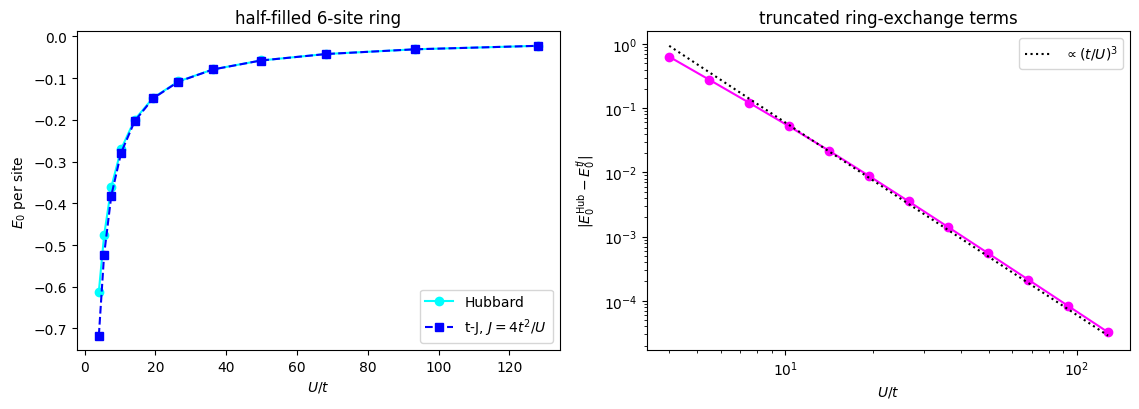

In [9]:
N6, bonds6, _ = build_lattice('chain', 6, J=0.0, t=T_HOP, pbc=True)
_, bondsJ1, _ = build_lattice('chain', 6, J=1.0, t=T_HOP, pbc=True)
E_heis1 = diagonalise(H_tJ(N6, bondsJ1, 3, 3)[0], 'full', 1)[0][0]   # E_tJ at J = 1

Us = np.geomspace(4.0, 128.0, 12)
E_hub = np.array([diagonalise(H_hubbard(N6, bonds6, 3, 3, Uv)[0], 'full', 1)[0][0]
                  for Uv in Us])
E_tJ = E_heis1 * 4*T_HOP**2/Us

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.2))
axL.plot(Us, E_hub/N6, 'o-', label='Hubbard', c='cyan')
axL.plot(Us, E_tJ/N6, 's--', label=r't-J, $J = 4t^2/U$', c='blue')
axL.set_xlabel(r'$U/t$'); axL.set_ylabel(r'$E_0$ per site')
axL.set_title('half-filled 6-site ring'); axL.legend()
axR.loglog(Us, np.abs(E_hub - E_tJ), 'o-', c='magenta')
axR.loglog(Us, 60.0*Us**-3.0, 'k:', label=r'$\propto (t/U)^3$')
axR.set_xlabel(r'$U/t$'); axR.set_ylabel(r'$|E_0^{\mathrm{Hub}} - E_0^{tJ}|$')
axR.set_title('truncated ring-exchange terms'); axR.legend()
plt.tight_layout(); plt.show()

## 8  Results for the chosen parameters

Both models on the lattice and sector selected in Section 1.

In [10]:
N, bonds, xy = build_lattice(LATTICE, L, J=J_EX, t=T_HOP, alpha=ALPHA, pbc=PBC)
Nup = N_UP if N_UP is not None else (N + 1)//2
Ndn = N_DN if N_DN is not None else N//2

print(f"{LATTICE}, L = {L} ({N} sites, PBC = {PBC}), sector (N_up, N_dn) = ({Nup}, {Ndn}), "
      f"method = {METHOD!r}")
print(f"t = {T_HOP}, U = {U_INT}, J = {J_EX}"
      + (f", alpha = {ALPHA}" if LATTICE == 'checkerboard' else ""))
print("t-J exchange: " + ("J (S_i.S_j - n_i n_j/4)  [standard t-J]" if TJ_DENSITY_TERM
                          else "J S_i.S_j  [pure Heisenberg, no density term]"))
if Nup + Ndn == N:
    print("half filling: the t-J kinetic term is frozen (Heisenberg limit)")
print()


if MODEL == 'hubbard':
    name, builder = ("Hubbard", lambda: H_hubbard(N, bonds, Nup, Ndn, U_INT))
elif MODEL == 'tJ':
    name, builder = ("t-J",     lambda: H_tJ(N, bonds, Nup, Ndn, density_term=TJ_DENSITY_TERM))
else:
    raise ValueError(f"unknown method {kind!r}")

t0 = time.time(); H, basis = builder(); t_build = time.time() - t0
t0 = time.time(); w, _, used = diagonalise(H, METHOD, K_EIGS); t_diag = time.time() - t0
print(f"{name:>8}: dim {H.shape[0]:>9,}  nnz {H.nnz:>11,}   "
      f"build {t_build:6.2f}s   diag {t_diag:6.2f}s  ({used})")
print(f"          E0 = {w[0]:+.8f}   E0/site = {w[0]/N:+.8f}")
print(f"          lowest {len(w)}: " + "  ".join(f"{e:+.6f}" for e in w))
print()

checkerboard, L = 4 (16 sites, PBC = True), sector (N_up, N_dn) = (8, 7), method = 'auto'
t = 1.0, U = 8.0, J = 0.0, alpha = 1.0
t-J exchange: J S_i.S_j  [pure Heisenberg, no density term]

     t-J: dim   102,960  nnz     720,720   build   0.08s   diag   0.28s  (lanczos)
          E0 = -4.00000000   E0/site = -0.25000000
          lowest 4: -4.000000  -4.000000  -4.000000  -3.869424



## 9  Matrix-free diagonalisation for large sectors

Sections 4–7 build the sparse matrix and hand it to the solver. Past a point the matrix itself — its `nnz` nonzeros — is the memory wall, well before the basis is. 
Lanczos (eigsh) only ever needs to compute $H\cdot v$, never $H$ itself. So instead of building and storing the sparse matrix, we can give eigsh a `LinearOperator` that knows how to apply $H$ to a vector. That removes the `nnz` memory wall. Both models get such an operator, but with very different gains:

**Hubbard (`hubbard_apply`)**: Because $H = K_\uparrow\otimes\mathbb{1}
+ \mathbb{1}\otimes K_\downarrow + U\,\mathrm{diag}$, the state vector reshaped to
$\Psi_{i_\uparrow i_\downarrow}$ obeys

$$H\Psi \;=\; K_\uparrow\,\Psi \;+\; \Psi\,K_\downarrow^{\mathsf T} \;+\; U\,(\mathrm{docc}\circ\Psi).$$

The Kronecker product is never formed: we store only the tiny single-species $K_\sigma$ (size $\binom{N}{N_\sigma}\!\approx\!\sqrt{\dim}$) and apply two sparse-times-dense products. **Should be lower memory *and* faster than building the full matrix!**

**t-J (`tJ_apply`)**: The constrained connectivity does not factorise, so the operator recomputes the hop/exchange scatter on every matvec straight from the $O(\dim)$ two-mask basis, holding no $O(\mathrm{nnz})$ matrix. Each matvec costs about one matrix assembly, so a Lanczos solve is $\sim$(iterations) times slower than the
stored path. 
Thus this is gives lower memory use at the cost of time. **Only use this if the size of the sparse tJ matrix would exceed accesible memory!**

In [11]:
def hubbard_apply(N, bonds, Nup, Ndn, Uint):
    '''Matrix-free Hubbard H as a LinearOperator via H = K_up x I + I x K_dn + U diag,
    applied as K_up @ Psi + Psi @ K_dn.T + U docc o Psi (no kron, no O(nnz) storage).'''
    Sup, Sdn = spin_basis(N, Nup), spin_basis(N, Ndn)
    nu, nd = len(Sup), len(Sdn)
    Kup = hop_spin(N, bonds, Sup)
    KdnT = hop_spin(N, bonds, Sdn).T.tocsr()
    dvec = (Uint*hubbard_docc(Sup, Sdn)).reshape(nu, nd) if Uint != 0.0 else None
    def matvec(v):
        Psi = v.reshape(nu, nd)
        out = Kup @ Psi + Psi @ KdnT
        if dvec is not None: out += dvec*Psi
        return out.ravel()
    return (LinearOperator((nu*nd, nu*nd), matvec=matvec, rmatvec=matvec,
                           dtype=np.float64), (Sup, Sdn))

def tJ_apply(N, bonds, Nup, Ndn, density_term=True):
    '''Matrix-free t-J H as a LinearOperator. Recomputes the hop/exchange connectivity
    on each matvec from the O(dim) basis -- never stores the O(nnz) matrix. Use when the
    sparse t-J matrix will not fit; otherwise H_tJ + eigsh is faster.'''
    N_h, N_up = N - Nup - Ndn, Nup
    Uu, Dd = tJ_basis(N, N_h, N_up)
    E = Uu | Dd
    dim = len(Uu)
    cols0 = np.arange(dim, dtype=np.int64)
    occ_u = lambda p: ((Uu >> np.uint64(p)) & _ONE).astype(bool)
    occ_d = lambda p: ((Dd >> np.uint64(p)) & _ONE).astype(bool)
    diag = np.zeros(dim)                                   # parameter-free in v: once
    for (i, j, tb, Jb, _) in bonds:
        if Jb != 0.0:
            niu, nid, nju, njd = occ_u(i), occ_d(i), occ_u(j), occ_d(j)
            both = (niu | nid) & (nju | njd)
            szsz = (niu.astype(np.float64) - nid)*(nju.astype(np.float64) - njd)
            nn = 0.25 if density_term else 0.0
            diag += np.where(both, Jb*(0.25*szsz - nn), 0.0)

    def scatter(v, out, m, steps, coef):
        if not m.any(): return
        Um, Dm = Uu[m], Dd[m]
        sgn = np.zeros(int(m.sum()), dtype=np.int64)
        for (spin, p) in steps:
            below = (_ONE << np.uint64(p)) - _ONE
            if spin == 0:
                sgn ^= np.bitwise_count(Um & below).astype(np.int64) & 1
                Um = Um ^ (_ONE << np.uint64(p))
            else:
                sgn ^= (np.bitwise_count(Um).astype(np.int64)
                        + np.bitwise_count(Dm & below).astype(np.int64)) & 1
                Dm = Dm ^ (_ONE << np.uint64(p))
        r = basisstate_to_index(Um, Dm, N, N_h, N_up)                       # targets unique within a term
        out[r] += coef*(1.0 - 2.0*sgn.astype(np.float64))*v[cols0[m]]

    def matvec(v):
        out = diag*v
        for (i, j, tb, Jb, _) in bonds:
            for (c, d) in ((i, j), (j, i)):
                empt = ((E >> np.uint64(c)) & _ONE) == 0
                scatter(v, out, empt & occ_u(d), [(0, d), (0, c)], -tb)
                scatter(v, out, empt & occ_d(d), [(1, d), (1, c)], -tb)
            if Jb != 0.0:
                niu, nid, nju, njd = occ_u(i), occ_d(i), occ_u(j), occ_d(j)
                scatter(v, out, nju & nid, [(0, j), (1, j), (1, i), (0, i)], 0.5*Jb)
                scatter(v, out, niu & njd, [(0, i), (1, i), (1, j), (0, j)], 0.5*Jb)
        return out
    return (LinearOperator((dim, dim), matvec=matvec, rmatvec=matvec,
                           dtype=np.float64), (Uu, Dd))

def ground_state_mf(op, k=1):
    '''k lowest eigenvalues of a matrix-free operator via Lanczos (eigsh).'''
    return np.sort(eigsh(op, k=k, which='SA', tol=1e-9, maxiter=10000,
                         return_eigenvectors=False))

In [12]:
# ---- validation: matrix-free operators reproduce the stored builders ----
rng = np.random.default_rng(1)
print("matrix-free apply == stored matrix (random-vector and ground-state checks)")
print("="*74)
for kind, Lv, pb, al, sec, Uv in [('chain', 10, True, 1.0, (4, 4), 8.0),
                                  ('square', 4, True, 1.0, (3, 3), 6.0),
                                  ('checkerboard', 4, True, 0.7, (3, 3), 5.0)]:
    N_, bonds_, _ = build_lattice(kind, Lv, J=0.4, t=T_HOP, alpha=al, pbc=pb)
    # Hubbard
    Hh, _ = H_hubbard(N_, bonds_, *sec, Uv)
    oph, _ = hubbard_apply(N_, bonds_, *sec, Uv)
    v = rng.normal(size=Hh.shape[0])
    dmv = np.abs(oph @ v - Hh @ v).max()
    Ed = np.linalg.eigvalsh(Hh.toarray())[0] if Hh.shape[0] <= 2000 \
         else np.sort(eigsh(Hh, k=1, which='SA')[0])[0]
    Em = ground_state_mf(oph, 1)[0]
    assert dmv < 1e-10 and abs(Ed - Em) < 1e-8
    # t-J
    Ht, _ = H_tJ(N_, bonds_, *sec, density_term=TJ_DENSITY_TERM)
    opt, _ = tJ_apply(N_, bonds_, *sec, density_term=TJ_DENSITY_TERM)
    vt = rng.normal(size=Ht.shape[0])
    dmt = np.abs(opt @ vt - Ht @ vt).max()
    Etd = np.linalg.eigvalsh(Ht.toarray())[0] if Ht.shape[0] <= 2000 \
          else np.sort(eigsh(Ht, k=1, which='SA')[0])[0]
    Etm = ground_state_mf(opt, 1)[0]
    assert dmt < 1e-10 and abs(Etd - Etm) < 1e-8
    print(f"{kind:>12}, L = {Lv:>2}, sec = {sec}: dim {Hh.shape[0]:>7,}  matvec diff {dmv:.1e}  "
          f"E0 {Em:+.4f} | t-J dim {Ht.shape[0]:>6,}  matvec diff {dmt:.1e}  E0 {Etm:+.3f}")
print("\nMatrix-free operators agree with the stored matrices")

matrix-free apply == stored matrix (random-vector and ground-state checks)
       chain, L = 10, sec = (4, 4): dim  44,100  matvec diff 2.8e-14  E0 -6.0763 | t-J dim  3,150  matvec diff 1.8e-15  E0 -4.772
      square, L =  4, sec = (3, 3): dim 313,600  matvec diff 2.8e-14  E0 -14.8956 | t-J dim 160,160  matvec diff 7.1e-15  E0 -13.862
checkerboard, L =  4, sec = (3, 3): dim 313,600  matvec diff 2.1e-14  E0 -17.7175 | t-J dim 160,160  matvec diff 1.1e-14  E0 -16.062

Matrix-free operators agree with the stored matrices


In [13]:
# ---- time and memory comparison (Hubbard) ----
L = 14; s = 5;
N_, bonds_, _ = build_lattice('chain', L, J=0.0, t=T_HOP, pbc=True)
sec = (s, s)
print(f"chain L=14, sector {sec}: dim = {comb(L,s)**2:,}\n")
t0 = time.time(); Hs, _ = H_hubbard(N_, bonds_, *sec, 8.0); t_build = time.time() - t0
mem_csr = (Hs.data.nbytes + Hs.indices.nbytes + Hs.indptr.nbytes)/1e9
t0 = time.time(); Es = np.sort(eigsh(Hs, k=1, which='SA', tol=1e-8)[0])[0]
t_stored = time.time() - t0
del Hs
t0 = time.time(); op, _ = hubbard_apply(N_, bonds_, *sec, 8.0); t_op = time.time() - t0
t0 = time.time(); Em = ground_state_mf(op, 1)[0]; t_mf = time.time() - t0
print(f"  stored : build {t_build:5.2f}s + solve {t_stored:5.2f}s, "
      f"CSR holds {mem_csr*1e3:.0f} MB of matrix")
print(f"mat-free : setup {t_op:5.2f}s + solve {t_mf:5.2f}s, stores only "
      f"K_up, K_dn ({comb(L,s):,} x {comb(L,s):,} each, ~sqrt(dim))")
print(f"\nE0 agree: stored {Es:+.8f}  matrix-free {Em:+.8f}  (diff {abs(Es-Em):.1e})")

chain L=14, sector (5, 5): dim = 4,008,004

  stored : build  0.67s + solve  9.11s, CSR holds 727 MB of matrix
mat-free : setup  0.01s + solve  8.53s, stores only K_up, K_dn (2,002 x 2,002 each, ~sqrt(dim))

E0 agree: stored -9.76293063  matrix-free -9.76293063  (diff 5.3e-15)
